# 03 EDA - Univariate

## Sales Distribution

This section plots the distribution of `Sales` using:
- Histogram
- Smooth density curve (KDE)
- Vertical lines for mean and median


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')


In [4]:
# Prefer cleaned dataset; fall back to raw if needed.
clean_path = Path('../data/processed/ElectraHub_Data_cleaned.csv')
raw_path = Path('../data/raw/ElectraHub_Data.csv')

data_path = clean_path if clean_path.exists() else raw_path
df = pd.read_csv(data_path)

print(f'Loaded: {data_path.name}')

print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')

Loaded: ElectraHub_Data_cleaned.csv
Rows: 3,000 | Columns: 16


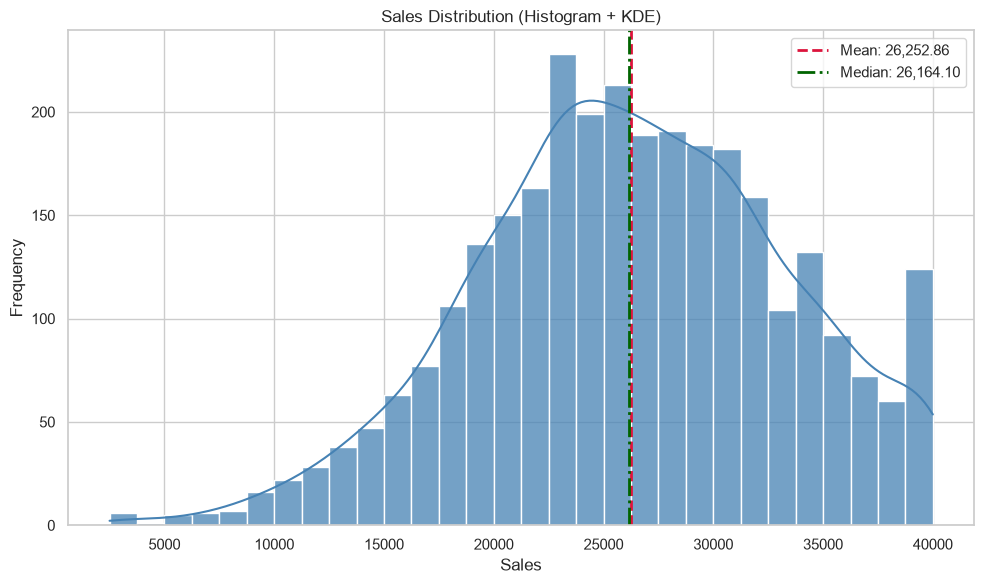

In [5]:
sales = df['Sales'].dropna()
sales_mean = sales.mean()
sales_median = sales.median()

plt.figure(figsize=(10, 6))
sns.histplot(sales, bins=30, kde=True, color='steelblue', edgecolor='white', alpha=0.75)

plt.axvline(sales_mean, color='crimson', linestyle='--', linewidth=2, label=f'Mean: {sales_mean:,.2f}')
plt.axvline(sales_median, color='darkgreen', linestyle='-.', linewidth=2, label=f'Median: {sales_median:,.2f}')

plt.title('Sales Distribution (Histogram + KDE)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
print(f'Sales Mean   : {sales_mean:,.2f}')
print(f'Sales Median : {sales_median:,.2f}')

if sales_mean > sales_median:
    print('Observation: Mean > median, suggesting a right-skewed distribution.')
elif sales_mean < sales_median:
    print('Observation: Mean < median, suggesting a left-skewed distribution.')
else:
    print('Observation: Mean and median are equal, suggesting near symmetry.')

Sales Mean   : 26,252.86
Sales Median : 26,164.10
Observation: Mean > median, suggesting a right-skewed distribution.


## Advertising Expenditure Distribution

Side-by-side view to assess spread, outliers, and symmetry:
- Left: Histogram with KDE curve
- Right: Box plot


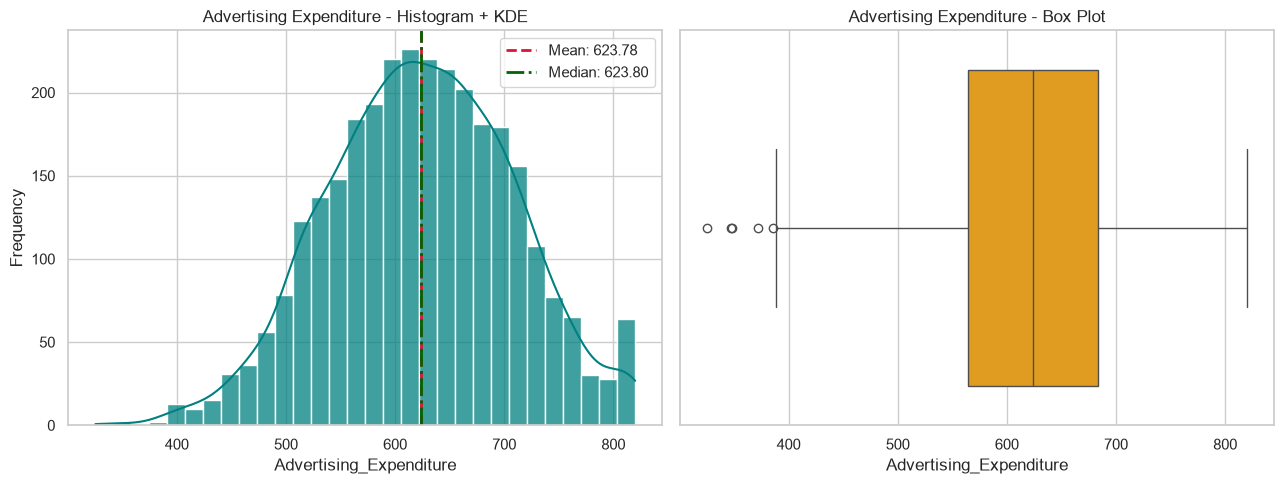

Mean                : 623.78
Median              : 623.80
Skewness            : -0.0543
IQR Outlier Count   : 5
IQR Bounds          : [385.79, 861.96]
Symmetry assessment : Approximately symmetric.


In [7]:
ad = df['Advertising_Expenditure'].dropna()

ad_mean = ad.mean()
ad_median = ad.median()
ad_skew = ad.skew()

q1 = ad.quantile(0.25)
q3 = ad.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_count = int(((ad < lower) | (ad > upper)).sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(ad, bins=30, kde=True, color='teal', edgecolor='white', alpha=0.75, ax=axes[0])
axes[0].axvline(ad_mean, color='crimson', linestyle='--', linewidth=2, label=f'Mean: {ad_mean:,.2f}')
axes[0].axvline(ad_median, color='darkgreen', linestyle='-.', linewidth=2, label=f'Median: {ad_median:,.2f}')
axes[0].set_title('Advertising Expenditure - Histogram + KDE')
axes[0].set_xlabel('Advertising_Expenditure')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x=ad, color='orange', ax=axes[1])
axes[1].set_title('Advertising Expenditure - Box Plot')
axes[1].set_xlabel('Advertising_Expenditure')

plt.tight_layout()
plt.show()

print(f'Mean                : {ad_mean:,.2f}')
print(f'Median              : {ad_median:,.2f}')
print(f'Skewness            : {ad_skew:.4f}')
print(f'IQR Outlier Count   : {outlier_count}')
print(f'IQR Bounds          : [{lower:,.2f}, {upper:,.2f}]')

if abs(ad_skew) < 0.5:
    print('Symmetry assessment : Approximately symmetric.')
elif ad_skew >= 0.5:
    print('Symmetry assessment : Positively skewed (right-tailed).')
else:
    print('Symmetry assessment : Negatively skewed (left-tailed).')

## Popularity Distribution

Bar chart for `Popularity` with business-meaningful order (not alphabetical):
`Very Low` → `Low` → `Moderate` → `High` → `Very High`.


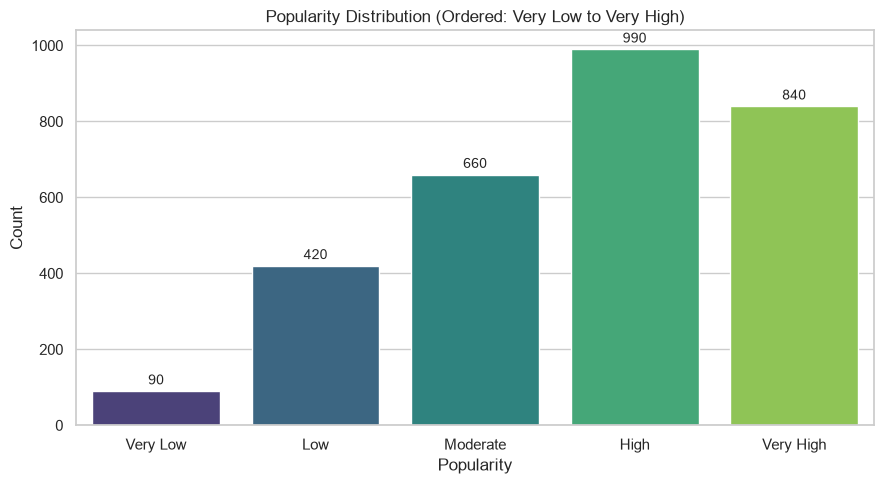

Counts by Popularity (Very Low -> Very High):
Popularity
Very Low      90
Low          420
Moderate     660
High         990
Very High    840


In [9]:
popularity_order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

pop_counts = (
    df['Popularity']
    .astype(str)
    .str.strip() #strip whitespace to normalize text data
    .value_counts()
    .reindex(popularity_order, fill_value=0)
)

plt.figure(figsize=(9, 5))
sns.barplot(x=pop_counts.index, y=pop_counts.values, hue=pop_counts.index, palette='viridis')
plt.title('Popularity Distribution (Ordered: Very Low to Very High)')
plt.xlabel('Popularity')
plt.ylabel('Count')

for i, v in enumerate(pop_counts.values):
    plt.text(i, v + max(pop_counts.values) * 0.01 if max(pop_counts.values) > 0 else 0.5, f'{int(v)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('Counts by Popularity (Very Low -> Very High):')
print(pop_counts.to_string())